### Импорты

In [ ]:
!pip install adjustText pymorphy3 pymorphy3-dicts-ru

In [ ]:
import os
import re
import torch
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from time import time
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from adjustText import adjust_text
import pymorphy3
from nltk.corpus import stopwords
import nltk

nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import sent_tokenize


In [ ]:
morph = pymorphy3.MorphAnalyzer()

### Загрузка и чтение текста

Обработка txt

In [ ]:
def load_and_clean_text(filepath):
    """Загружает текст и убирает маркеры глав."""
    with open(filepath, encoding="utf-8") as f:
        text = f.read()

    # Убирает «Глава ...» и его вариации (для русского текста)
    text = re.sub(r'^\s*глава\b.*$', '', text, flags=re.IGNORECASE | re.MULTILINE)
    text = re.sub(r'^\s*часть\b.*$', '', text, flags=re.IGNORECASE | re.MULTILINE)

    return text

In [ ]:
def split_into_sentences(text):
    sentences = sent_tokenize(text, language='russian')
    return [s.strip() for s in sentences if len(s.strip()) > 10]

In [ ]:
master_text = load_and_clean_text("")  # путь к txt
master_sentences = split_into_sentences(master_text)

Сохранение в датафрейм

In [ ]:
mm_sent = pd.DataFrame({"sentence": master_sentences})

In [ ]:
''' Cохранить датафрейм в формате csv '''
mm_sent.to_csv('/mm_sentences_rumbert.csv', sep='\t', index=False)

Загрузка подготовленного текста

In [ ]:
'''Загрузка датасета'''
mm_sent = pd.read_csv("/mm_sentences_rumbert.csv", sep='\t')

In [ ]:
master_sentences = mm_sent['sentence'].to_list()

### Загрузка модели


In [ ]:
MODEL_NAME = "deepvk/RuModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("device:", device)
print("hidden_size:", model.config.hidden_size)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/837 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


device: cuda
hidden_size: 768


### Функции

In [ ]:
def get_russian_word_pattern(base_lemma: str) -> str:
    """
    Строит regex-паттерн, который ловит все словоформы заданной леммы.
    Пример: 'любить' → r'(?<![а-яёА-ЯЁ])(люблю|любишь|любит|любим|любят|любил|любила|любить)(?![а-яёА-ЯЁ])'
    """
    parsed = morph.parse(base_lemma)[0]
    forms = set()
    for f in parsed.lexeme:
        forms.add(f.word.lower())
    forms_sorted = sorted(forms, key=len, reverse=True)  # длинные первыми — жадный match
    pattern = '|'.join(re.escape(w) for w in forms_sorted)
    return rf'(?<![а-яёА-ЯЁ])({pattern})(?![а-яёА-ЯЁ])'

In [ ]:
def extract_word_contexts(concept_word, sentences, pattern, max_contexts=500):
    """
    Находит все предложения, содержащие целевое слово/словоформы по regex-pattern.
    """
    contexts = []
    for idx, sentence in enumerate(sentences):
        if re.search(pattern, sentence, re.IGNORECASE):
            contexts.append((sentence, idx))
            if len(contexts) >= max_contexts:
                break
    print(f"✓ Найдено {len(contexts)} контекстов")
    return contexts

In [ ]:
def build_contextual_embeddings(concept_word, sentences, tokenizer, model, device, max_contexts=500, pattern=None):
    """
    Главная функция для построения контекстуальных эмбеддингов.
    """
    if pattern is None:
        # дефолт: искать точную форму (на всякий случай)
        pattern = rf'(?<![а-яёА-ЯЁ])({re.escape(concept_word.lower())})(?![а-яёА-ЯЁ])'

    print(f"\n🔍 Поиск контекстов для '{concept_word}'...")
    contexts = extract_word_contexts(concept_word, sentences, pattern, max_contexts=max_contexts)

    if len(contexts) == 0:
        print(f"❌ Слово '{concept_word}' не найдено в тексте!")
        return None, [], None

    print(f"📊 Генерация эмбеддингов в контексте...")

    word_vectors = []
    valid_contexts = []

    for i, (sentence, sent_idx) in enumerate(contexts):
        if i % max(1, len(contexts) // 10) == 0:
            print(f"  {i}/{len(contexts)}", end='\r')

        try:
            vec = get_word_vector_in_context(concept_word, sentence, tokenizer, model, device, pattern=pattern)
            if vec is not None:
                word_vectors.append(vec)
                valid_contexts.append((sentence, sent_idx))

        except Exception as e:
            continue

    if len(word_vectors) == 0:
        print(f"❌ Не удалось извлечь векторы для '{concept_word}'!")
        return None, [], None

    word_vectors = np.array(word_vectors)
    avg_vector = word_vectors.mean(axis=0)
    avg_vector = avg_vector / (np.linalg.norm(avg_vector) + 1e-9)

    print(f"✓ Обработано {len(word_vectors)} контекстов\n")

    return word_vectors, valid_contexts, avg_vector


In [ ]:
def get_word_vector_in_context(word, sentence, tokenizer, model, device, pattern=None):
    """
    Возвращает вектор первой найденной словоформы по regex-pattern в предложении.
    """

    if pattern is None:
        # дефолт на случай точной формы
        pattern = rf'(?<![а-яёА-ЯЁ])({re.escape(word.lower())})(?![а-яёА-ЯЁ])'

    with torch.no_grad():
        encoded = tokenizer(
            sentence,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            return_offsets_mapping=True
        )

        offsets = encoded['offset_mapping'][0].tolist()
        outputs = model(
            input_ids=encoded['input_ids'].to(device),
            attention_mask=encoded['attention_mask'].to(device)
        )
        hidden_states = outputs.last_hidden_state[0].cpu().numpy()

    sentence_lower = sentence.lower()

    match = re.search(pattern, sentence_lower, re.IGNORECASE)
    if not match:
        return None

    # берем именно группу с самой словоформой
    word_start = match.start(1)
    word_end = match.end(1)

    target_indices = []
    for i, (start, end) in enumerate(offsets):
        if end <= word_start:
            continue
        if start >= word_end:
            break
        if start == 0 and end == 0:
            continue
        target_indices.append(i)

    if not target_indices:
        return None

    word_vector = hidden_states[target_indices].mean(axis=0)
    return word_vector

In [ ]:
def build_contextual_vocab_embeddings(
    concept_word,
    all_sentences,
    tokenizer,
    model,
    device,
    max_vocab_words=100,
    max_contexts_per_word=30,
    min_freq=5,
):
    stopwords_set = set(stopwords.words("russian"))

    print("🔤 Построение контекстного словаря из ВСЕГО текста...")

    # 1. Частотный словарь по всему роману
    all_words_counter = Counter()
    for sentence in all_sentences:
        words = re.findall(r"[а-яё]+", sentence.lower())
        for w in words:
            if w not in stopwords_set and len(w) > 2 and w != concept_word.lower():
                all_words_counter[w] += 1

    # 2. Фильтр по частоте
    frequent_words = [(w, c) for w, c in all_words_counter.items() if c >= min_freq]
    frequent_words.sort(key=lambda x: x[1], reverse=True)
    top_words = [w for w, c in frequent_words[:max_vocab_words * 3]]  # берём с запасом

    print(f"✓ Собрано {len(top_words)} словоформ для анализа (из {len(all_words_counter)} уникальных, freq ≥ {min_freq})")

    # 3. ▶ НОВОЕ: группируем словоформы по леммам через pymorphy3
    lemma_to_forms = defaultdict(list)
    for w in top_words:
        lemma = morph.parse(w)[0].normal_form
        if lemma != concept_word.lower():
            lemma_to_forms[lemma].append(w)

    # Оставляем только top-N лемм по суммарной частоте
    lemma_freq = {
        lemma: sum(all_words_counter[f] for f in forms)
        for lemma, forms in lemma_to_forms.items()
    }
    top_lemmas = sorted(lemma_freq, key=lemma_freq.get, reverse=True)[:max_vocab_words]

    print(f"✓ После лемматизации: {len(top_lemmas)} уникальных лемм")

    word2vec_contextual = {}

    print("📊 Генерация контекстных эмбеддингов для лемм...")

    for i, lemma in enumerate(top_lemmas):
        if i % max(1, len(top_lemmas) // 10) == 0:
            print(f"  {i}/{len(top_lemmas)} лемм обработано")

        forms = lemma_to_forms[lemma]
        vectors_for_lemma = []

        # 4. Для каждой словоформы — ищем контексты и извлекаем векторы
        for form in forms:
            form_pattern = rf"(?<![а-яёА-ЯЁ])({re.escape(form)})(?![а-яёА-ЯЁ])"
            form_sentences = [
                s for s in all_sentences
                if re.search(form_pattern, s, re.IGNORECASE)
            ]

            for sent in form_sentences[:max_contexts_per_word]:
                try:
                    # предложение идёт в BERT необработанным!
                    vec = get_word_vector_in_context(
                        form, sent, tokenizer, model, device, pattern=form_pattern
                    )
                    if vec is not None:
                        vectors_for_lemma.append(vec)
                except Exception:
                    continue

        # 5. Усредняем по всем словоформам и контекстам
        if vectors_for_lemma:
            avg_vec = np.mean(np.vstack(vectors_for_lemma), axis=0)
            avg_vec = avg_vec / (np.linalg.norm(avg_vec) + 1e-9)
            word2vec_contextual[lemma] = avg_vec  # ключ — лемма

    print(f"✓ Получены векторы для {len(word2vec_contextual)} лемм\n")

    return word2vec_contextual

In [ ]:
def find_semantic_associates(concept_vector, word2vec_contextual, topn=20):
    """
    Находит слова, семантически близкие к концепту в контексте романа.
    """

    similarities = []

    for word, word_vec in word2vec_contextual.items():
        cos_sim = np.dot(concept_vector, word_vec)
        similarities.append((word, cos_sim))

    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:topn]

In [ ]:
def visualize_contextual_semantic_field(
    concept_word,
    concept_vector,
    word2vec_contextual,
    valid_contexts,
    topn=80,
):
    print(f"\n📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)\n")

    # 1. Поиск ассоциатов
    print("Шаг 0/3: поиск ассоциатов...")
    associates = find_semantic_associates(concept_vector, word2vec_contextual, topn=topn)
    associate_words = [w for w, _ in associates]

    all_words = [concept_word] + associate_words
    all_vectors = np.vstack(
        [concept_vector] + [word2vec_contextual[w] for w in associate_words]
    )
    print(f"✓ Собрано {len(all_words)} слов для визуализации")

    # 2. K-Means в исходном 768D пространстве
    print("Шаг 1/3: K-Means кластеризация в исходном пространстве...")
    n_clusters = max(1, min(5, len(all_words) // 8))
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42, verbose=0)
    labels = kmeans.fit_predict(all_vectors)
    print(f"✓ K-Means завершён: инерция={kmeans.inertia_:.2f}, кластеров={n_clusters}")

    if n_clusters > 1 and len(all_words) > n_clusters:
        sil = silhouette_score(all_vectors, labels)
        dbi = davies_bouldin_score(all_vectors, labels)
        print(f"  Silhouette score: {sil:.4f}")
        print(f"  Davies-Bouldin index: {dbi:.4f}")
    else:
        sil, dbi = None, None
        print("  Метрики кластеризации не считаются (мало кластеров/точек).")

    # 3. t-SNE для 2D-визуализации
    print("Шаг 2/3: t-SNE редукция до 2D...")
    perplexity = min(30, max(5, len(all_vectors) - 1))
    print(f"  точек={len(all_vectors)}, perplexity={perplexity}")
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity,
        learning_rate=200,
        init="pca",
        verbose=0,
    )
    vectors_2d = tsne.fit_transform(all_vectors)

    # 4. Построение графика
    print("Шаг 3/3: построение графика...")
    plt.rcParams["font.family"] = "DejaVu Sans"

    # Фиксированные цвета — строго один цвет на cluster_id
    base_colors = [
        "#1f77b4",  # синий
        "#2ca02c",  # зелёный
        "#8c564b",  # коричневый
        "#7f7f7f",  # серый
        "#17becf",  # голубой
        "#9467bd",  # фиолетовый
        "#d62728",  # красный
        "#ff7f0e",  # оранжевый
    ]
    color_names = [
        "синий", "зелёный", "коричневый", "серый",
        "голубой", "фиолетовый", "красный", "оранжевый",
    ]

    unique_clusters = sorted(np.unique(labels))
    cluster_to_color = {
        cid: base_colors[i % len(base_colors)]
        for i, cid in enumerate(unique_clusters)
    }
    cluster_to_color_name = {
        cid: color_names[i % len(color_names)]
        for i, cid in enumerate(unique_clusters)
    }

    fig, ax = plt.subplots(figsize=(24, 20))

    # Рисуем обычные слова по кластерам (без concept_word)
    for cluster_id in unique_clusters:
        idx_cluster = [
            i for i in range(len(all_words))
            if labels[i] == cluster_id and all_words[i] != concept_word
        ]
        if not idx_cluster:
            continue
        pts = vectors_2d[idx_cluster]
        ax.scatter(
            pts[:, 0], pts[:, 1],
            c=cluster_to_color[cluster_id],
            s=180,
            alpha=0.9,
            edgecolors="black",
            linewidth=0.8,
            label=f"Кластер {cluster_id}",
            zorder=2,
        )

    # Concept word поверх всех
    ci = all_words.index(concept_word)
    ax.scatter(
        vectors_2d[ci, 0], vectors_2d[ci, 1],
        c=cluster_to_color[labels[ci]],
        s=650,
        alpha=1.0,
        edgecolors="red",
        linewidth=2.5,
        zorder=5,
    )

    # Подписи — рамка текста окрашена в цвет кластера
    texts = []
    for i, w in enumerate(all_words):
        x, y = vectors_2d[i]
        if w == concept_word:
            t = ax.text(
                x, y, w.upper(),
                fontsize=14, fontweight="bold",
                bbox=dict(
                    facecolor="yellow", alpha=0.95,
                    edgecolor="red", boxstyle="round,pad=0.6", linewidth=3
                ),
                ha="center", va="center", zorder=6,
            )
        else:
            t = ax.text(
                x, y, w,
                fontsize=13, fontweight="bold",
                bbox=dict(
                    facecolor="white", alpha=0.85,
                    edgecolor=cluster_to_color[labels[i]],  # цвет рамки = цвет кластера
                    boxstyle="round,pad=0.3", linewidth=1.2
                ),
                ha="center", va="center", zorder=4,
            )
        texts.append(t)

    adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))

    ax.set_title(
        f"Лексико-семантическое поле '{concept_word}'\n"
        f"(Контекстные эмбеддинги RuModernBERT, K-Means + t-SNE)",
        fontsize=18, fontweight="bold", pad=20,
    )
    ax.set_xlabel("t-SNE dim 1", fontsize=12)
    ax.set_ylabel("t-SNE dim 2", fontsize=12)
    ax.legend(loc="upper right", fontsize=11)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    # 5. Статистика
    print(f"\n📈 Top-20 ассоциатов к '{concept_word}' (в контексте романа):\n")
    for i, (w, sim) in enumerate(associates[:20], 1):
        idx = all_words.index(w)
        cid = labels[idx]
        print(f"{i:2d}. {w:20s} similarity={sim:.4f}  кластер={cid} ({cluster_to_color_name[cid]})")

    print("\n🧩 Состав кластеров:\n")
    for cid in unique_clusters:
        words_in = [all_words[i] for i in range(len(all_words)) if labels[i] == cid]
        print(f"Кластер {cid} ({cluster_to_color_name[cid]}, {len(words_in)} слов):")
        print("  " + ", ".join(words_in))

        # Внутрикластерная косинусная близость
        vecs_in = np.array([all_vectors[i] for i in range(len(all_words)) if labels[i] == cid])
        if len(vecs_in) > 1:
            norms = vecs_in / np.linalg.norm(vecs_in, axis=1, keepdims=True)
            sim_matrix = norms @ norms.T
            n = len(vecs_in)
            avg_sim = (sim_matrix.sum() - n) / (n * (n - 1))
            print(f"  Средняя косинусная близость внутри кластера: {avg_sim:.4f}")

        # Близость центроида кластера к concept_word
        centroid = vecs_in.mean(axis=0)
        cv = concept_vector.squeeze()
        cos_to_concept = np.dot(centroid, cv) / (
            np.linalg.norm(centroid) * np.linalg.norm(cv)
        )
        print(f"  Близость к '{concept_word}': {cos_to_concept:.4f}\n")

    # 6. Примеры контекстов
    print(f"\n📝 Примеры контекстов слова '{concept_word}' в романе:\n")
    pattern = get_russian_word_pattern(concept_word)
    for i, (sentence, _) in enumerate(valid_contexts[:5], 1):
        highlighted = re.sub(
            pattern,
            lambda m: f">>> {m.group(0)} <<<",
            sentence,
            flags=re.IGNORECASE,
        )
        print(f"{i}. {highlighted}\n")

    return all_words, vectors_2d, labels, cluster_to_color, cluster_to_color_name

## Mоделирование поля

### Моделирование поля отдельно для **любить**



🔍 Поиск контекстов для 'любить'...
✓ Найдено 31 контекстов
📊 Генерация эмбеддингов в контексте...
✓ Обработано 31 контекстов

🔤 Построение контекстного словаря из ВСЕГО текста...
✓ Собрано 900 словоформ для анализа (из 23417 уникальных, freq ≥ 8)
✓ После лемматизации: 300 уникальных лемм
📊 Генерация контекстных эмбеддингов для лемм...
  0/300 лемм обработано
  30/300 лемм обработано
  60/300 лемм обработано
  90/300 лемм обработано
  120/300 лемм обработано
  150/300 лемм обработано
  180/300 лемм обработано
  210/300 лемм обработано
  240/300 лемм обработано
  270/300 лемм обработано
✓ Получены векторы для 300 лемм


📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)

Шаг 0/3: поиск ассоциатов...
✓ Собрано 81 слов для визуализации
Шаг 1/3: K-Means кластеризация в исходном пространстве...
✓ K-Means завершён: инерция=10.88, кластеров=5
  Silhouette score: 0.0621
  Davies-Bouldin index: 3.0644
Шаг 2/3: t-SNE редукция до 2D...
  точек=81, perplexity=30
Шаг 3/3: построение графика...


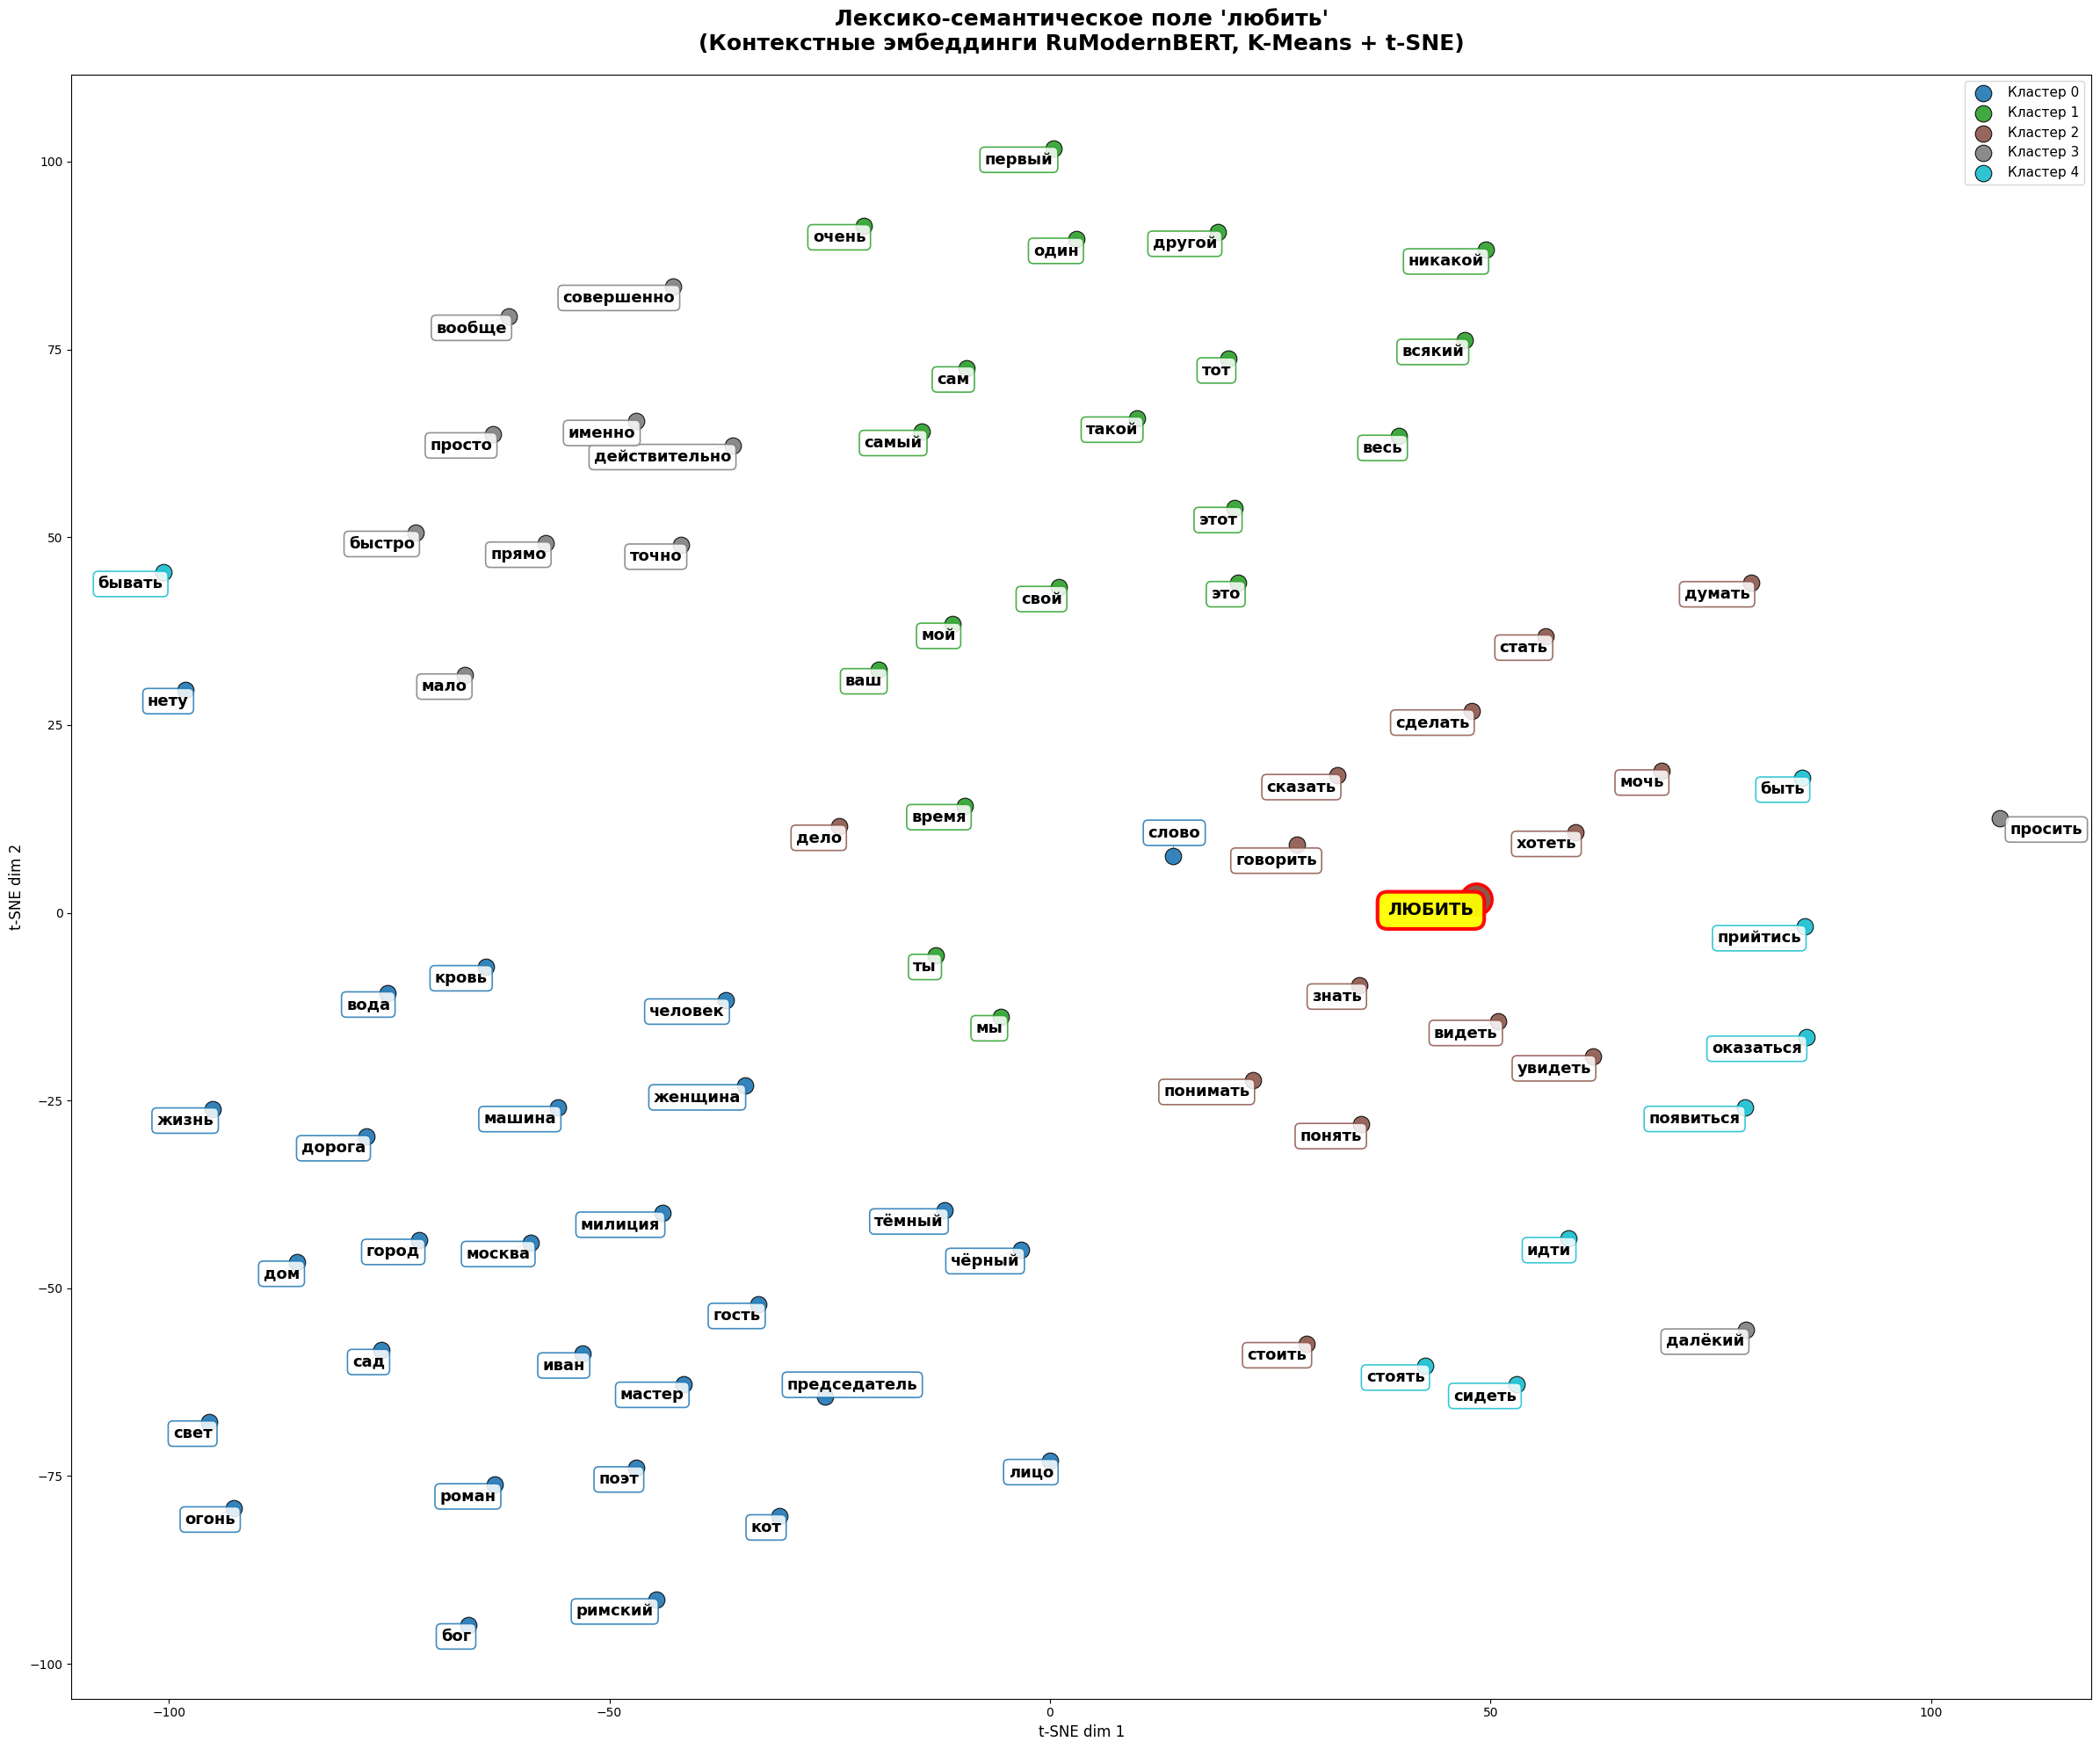


📈 Top-20 ассоциатов к 'любить' (в контексте романа):

 1. видеть               similarity=0.8916  кластер=2 (коричневый)
 2. хотеть               similarity=0.8915  кластер=2 (коричневый)
 3. говорить             similarity=0.8866  кластер=2 (коричневый)
 4. знать                similarity=0.8823  кластер=2 (коричневый)
 5. человек              similarity=0.8729  кластер=0 (синий)
 6. действительно        similarity=0.8711  кластер=3 (серый)
 7. весь                 similarity=0.8669  кластер=1 (зелёный)
 8. ваш                  similarity=0.8655  кластер=1 (зелёный)
 9. мой                  similarity=0.8652  кластер=1 (зелёный)
10. мочь                 similarity=0.8650  кластер=2 (коричневый)
11. просить              similarity=0.8645  кластер=3 (серый)
12. сам                  similarity=0.8639  кластер=1 (зелёный)
13. быть                 similarity=0.8638  кластер=4 (голубой)
14. гость                similarity=0.8635  кластер=0 (синий)
15. сказать              similarity=0.8630

In [ ]:
concept = "любить"

word_vectors, contexts, concept_vector = build_contextual_embeddings(
    concept,
    master_sentences,
    tokenizer,
    model,
    device,
    max_contexts=500,
    pattern=get_russian_word_pattern(concept)
)

word2vec_contextual = build_contextual_vocab_embeddings(
    concept,
    master_sentences,
    tokenizer,
    model,
    device,
    max_vocab_words=300,
    max_contexts_per_word=20,
    min_freq=8
)

if concept_vector is None:
    print(f"⚠ Концепт-вектор для '{concept}' не построен, визуализация невозможна.")
else:
    all_words, vectors_2d, labels, sil, dbi = visualize_contextual_semantic_field(
        concept,
        concept_vector,
        word2vec_contextual,
        contexts,
        topn=80
    )

Метрики кластеризации по **любить**
```
Слов: 80, меток: 80, векторов: 80
Коэффициент силуэта: 0.0623
Индекс Дэвиса-Болдина: 3.0518

Средняя косинусная близость внутри кластеров:
  Кластер 0: 0.8622 (слов: 28)
  Кластер 1: 0.8547 (слов: 19)
  Кластер 2: 0.8502 (слов: 14)
  Кластер 3: 0.8578 (слов: 11)
  Кластер 4: 0.8503 (слов: 8)

Близость кластеров к 'love':
  Кластер 0 (человек, гость, женщина...): 0.9133
  Кластер 1 (весь, ваш, мой...): 0.9187
  Кластер 2 (видеть, хотеть, говорить...): 0.9305
  Кластер 3 (действительно, просить, вообще...): 0.9130
  Кластер 4 (быть, идти, сидеть...): 0.9166
Состав кластеров:

Кластер 0 (28 слов):
  человек, гость, женщина, дорога, слово, дом, жизнь, город, мастер, поэт, иван, бог, роман, вода, машина, тёмный, председатель, кровь, москва, чёрный, сад, лицо, свет, нету, милиция, огонь, кот, римский

Кластер 1 (19 слов):
  весь, ваш, мой, сам, такой, этот, один, очень, первый, мы, всякий, ты, другой, самый, это, тот, свой, никакой, время

Кластер 2 (14 слов):
  видеть, хотеть, говорить, знать, мочь, сказать, увидеть, сделать, понимать, стоить, понять, дело, думать, стать

Кластер 3 (11 слов):
  действительно, просить, вообще, просто, мало, именно, далёкий, точно, быстро, совершенно, прямо

Кластер 4 (8 слов):
  быть, идти, сидеть, появиться, стоять, оказаться, прийтись, бывать
```

### Моделирования поля отдельно для **любовь**


🔍 Поиск контекстов для 'любовь'...
✓ Найдено 8 контекстов
📊 Генерация эмбеддингов в контексте...
✓ Обработано 8 контекстов

🔤 Построение контекстного словаря из ВСЕГО текста...
✓ Собрано 900 словоформ для анализа (из 23416 уникальных, freq ≥ 8)
✓ После лемматизации: 300 уникальных лемм
📊 Генерация контекстных эмбеддингов для лемм...
  0/300 лемм обработано
  30/300 лемм обработано
  60/300 лемм обработано
  90/300 лемм обработано
  120/300 лемм обработано
  150/300 лемм обработано
  180/300 лемм обработано
  210/300 лемм обработано
  240/300 лемм обработано
  270/300 лемм обработано
✓ Получены векторы для 300 лемм


📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)

Шаг 0/3: поиск ассоциатов...
✓ Собрано 81 слов для визуализации
Шаг 1/3: K-Means кластеризация в исходном пространстве...
✓ K-Means завершён: инерция=10.38, кластеров=5
  Silhouette score: 0.0553
  Davies-Bouldin index: 3.3107
Шаг 2/3: t-SNE редукция до 2D...
  точек=81, perplexity=30
Шаг 3/3: построение графика...


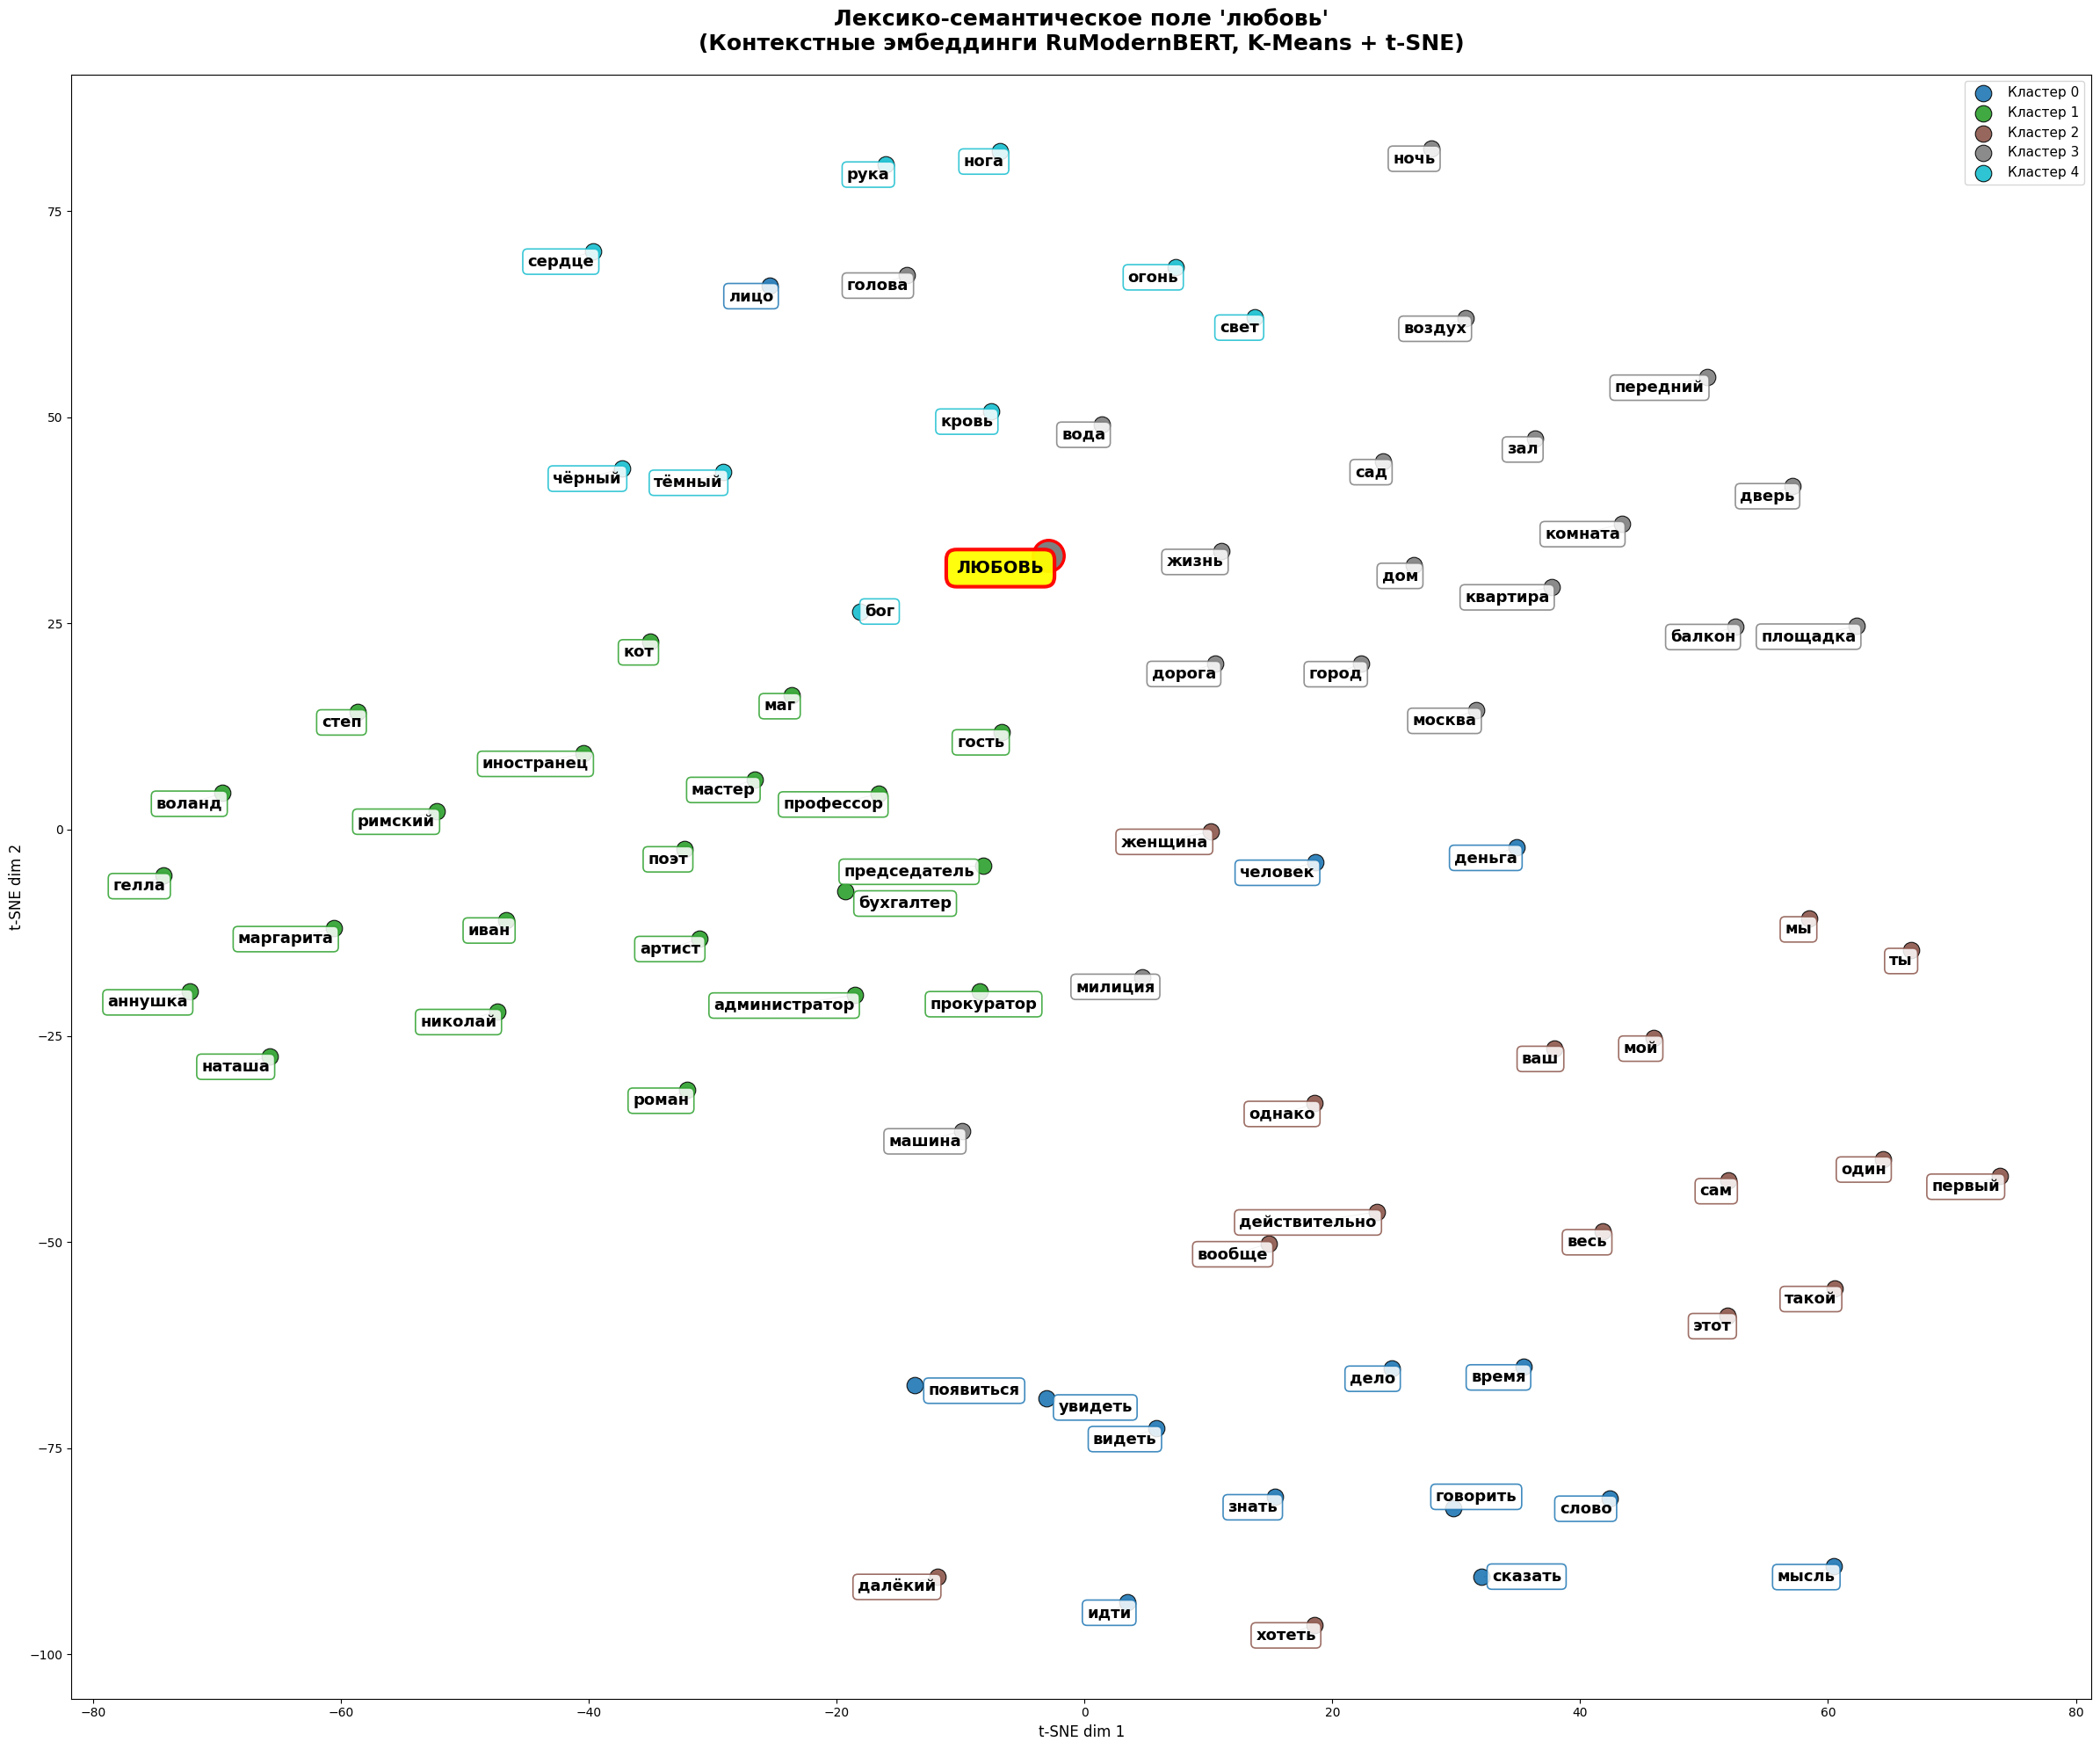


📈 Top-20 ассоциатов к 'любовь' (в контексте романа):

 1. кровь                similarity=0.8647  кластер=4 (голубой)
 2. жизнь                similarity=0.8620  кластер=3 (серый)
 3. дорога               similarity=0.8581  кластер=3 (серый)
 4. вода                 similarity=0.8558  кластер=3 (серый)
 5. женщина              similarity=0.8553  кластер=2 (коричневый)
 6. поэт                 similarity=0.8549  кластер=1 (зелёный)
 7. гость                similarity=0.8533  кластер=1 (зелёный)
 8. дом                  similarity=0.8515  кластер=3 (серый)
 9. машина               similarity=0.8507  кластер=3 (серый)
10. квартира             similarity=0.8499  кластер=3 (серый)
11. город                similarity=0.8493  кластер=3 (серый)
12. мастер               similarity=0.8488  кластер=1 (зелёный)
13. роман                similarity=0.8488  кластер=1 (зелёный)
14. человек              similarity=0.8467  кластер=0 (синий)
15. бог                  similarity=0.8465  кластер=4 (голубой

In [ ]:
concept = "любовь"

word_vectors, contexts, concept_vector = build_contextual_embeddings(
    concept,
    master_sentences,
    tokenizer,
    model,
    device,
    max_contexts=500,
    pattern=get_russian_word_pattern(concept)
)

word2vec_contextual = build_contextual_vocab_embeddings(
    concept,
    master_sentences,
    tokenizer,
    model,
    device,
    max_vocab_words=300,
    max_contexts_per_word=20,
    min_freq=8
)

if concept_vector is None:
    print(f"⚠ Концепт-вектор для '{concept}' не построен, визуализация невозможна.")
else:
    all_words, vectors_2d, labels, sil, dbi = visualize_contextual_semantic_field(
        concept,
        concept_vector,
        word2vec_contextual,
        contexts,
        topn=80
    )

Метрики кластеризации по **любовь**
```
Слов: 80, меток: 80, векторов: 80
Коэффициент силуэта: 0.0562
Индекс Дэвиса-Болдина: 3.2735

Средняя косинусная близость внутри кластеров:
  Кластер 0: 0.8467 (слов: 14)
  Кластер 1: 0.8830 (слов: 22)
  Кластер 2: 0.8522 (слов: 16)
  Кластер 3: 0.8669 (слов: 19)
  Кластер 4: 0.8583 (слов: 9)

Близость кластеров к 'love':
  Кластер 0 (человек, слово, говорить...): 0.8931
  Кластер 1 (поэт, гость, мастер...): 0.8821
  Кластер 2 (женщина, весь, мой...): 0.8921
  Кластер 3 (жизнь, дорога, вода...): 0.8965
  Кластер 4 (кровь, бог, рука...): 0.8920
Состав кластеров:

Кластер 0 (14 слов):
  человек, слово, говорить, видеть, мысль, сказать, деньга, лицо, дело, знать, идти, увидеть, появиться, время

Кластер 1 (22 слов):
  поэт, гость, мастер, роман, иван, маргарита, римский, маг, артист, председатель, кот, профессор, аннушка, администратор, иностранец, степ, николай, бухгалтер, гелла, наташа, воланд, прокуратор

Кластер 2 (16 слов):
  женщина, весь, мой, ваш, этот, действительно, ты, один, сам, хотеть, мы, первый, такой, далёкий, однако, вообще

Кластер 3 (19 слов):
  жизнь, дорога, вода, дом, машина, квартира, город, милиция, москва, голова, зал, сад, комната, ночь, площадка, дверь, балкон, воздух, передний

Кластер 4 (9 слов):
  кровь, бог, рука, огонь, свет, сердце, тёмный, чёрный, нога
```


### Подбор количества кластеров

In [ ]:
def evaluate_k_range(all_vectors, k_min=2, k_max=10, random_state=42):
    results = []
    for k in range(k_min, k_max + 1):
        kmeans = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=random_state,
            verbose=0
        )
        labels = kmeans.fit_predict(all_vectors)

        sil = silhouette_score(all_vectors, labels)
        dbi = davies_bouldin_score(all_vectors, labels)
        inertia = kmeans.inertia_

        results.append((k, sil, dbi, inertia))
        print(f"k={k:2d} | silhouette={sil:.4f} | DBI={dbi:.4f} | inertia={inertia:.2f}")

    return results

In [ ]:
associates = find_semantic_associates(concept_vector, word2vec_contextual, topn=80)
associate_words = [w for w, _ in associates]

all_words = [concept] + associate_words
all_vectors = np.vstack([concept_vector] + [word2vec_contextual[w] for w in associate_words])

NameError: name 'concept_vector' is not defined

In [ ]:
# после того как построен словарь, найдены топ-80 и сформированы all_vectors:
results = evaluate_k_range(all_vectors, k_min=2, k_max=10)

k= 2 | silhouette=0.0692 | DBI=3.3262 | inertia=14.43
k= 3 | silhouette=0.0677 | DBI=2.8093 | inertia=13.60
k= 4 | silhouette=0.0680 | DBI=3.0544 | inertia=12.98
k= 5 | silhouette=0.0726 | DBI=2.7313 | inertia=12.39
k= 6 | silhouette=0.0725 | DBI=2.7216 | inertia=12.12
k= 7 | silhouette=0.0724 | DBI=2.6719 | inertia=11.78
k= 8 | silhouette=0.0641 | DBI=2.5181 | inertia=11.44
k= 9 | silhouette=0.0590 | DBI=2.4529 | inertia=11.23
k=10 | silhouette=0.0674 | DBI=2.4041 | inertia=10.97


### Метрики

In [ ]:
# Собираем матрицу векторов топ-80 слов
filtered = [(w, l) for w, l in zip(all_words, labels) if w in word2vec_contextual]
top_words_list = [w for w, l in filtered]
top_labels_arr = np.array([l for w, l in filtered])
top_vectors = np.array([word2vec_contextual[w] for w in top_words_list])

print(f"Слов: {len(top_words_list)}, меток: {len(top_labels_arr)}, векторов: {len(top_vectors)}")

# 1. Silhouette Score (чем ближе к 1 — тем лучше кластеры)
sil = silhouette_score(top_vectors, top_labels_arr)
print(f"Коэффициент силуэта: {sil:.4f}")

# 2. Davies-Bouldin Index (чем меньше — тем лучше)
db = davies_bouldin_score(top_vectors, top_labels_arr)
print(f"Индекс Дэвиса-Болдина: {db:.4f}")

# 3. Средняя косинусная близость внутри каждого кластера
print("\nСредняя косинусная близость внутри кластеров:")
for cluster_id in sorted(set(top_labels_arr)):
    cluster_vectors = top_vectors[np.array(top_labels_arr) == cluster_id]
    if len(cluster_vectors) > 1:
        sim_matrix = cosine_similarity(cluster_vectors)
        # Берём только верхний треугольник без диагонали
        upper = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]
        print(f"  Кластер {cluster_id}: {upper.mean():.4f} (слов: {len(cluster_vectors)})")

# 4. Косинусная близость каждого кластера к вектору 'love'
print("\nБлизость кластеров к 'love':")
for cluster_id in sorted(set(top_labels_arr)):
    cluster_vectors = top_vectors[top_labels_arr == cluster_id]
    centroid = cluster_vectors.mean(axis=0)
    sim = cosine_similarity([concept_vector], [centroid])[0][0]
    cluster_words = [w for w, l in zip(top_words_list, top_labels_arr) if l == cluster_id]
    print(f"  Кластер {cluster_id} ({', '.join(cluster_words[:3])}...): {sim:.4f}")

print("Состав кластеров:\n")
for cluster_id in sorted(set(top_labels_arr)):
    cluster_words = [w for w, l in zip(top_words_list, top_labels_arr) if l == cluster_id]
    print(f"Кластер {cluster_id} ({len(cluster_words)} слов):")
    print(f"  {', '.join(cluster_words)}")
    print()


Слов: 80, меток: 80, векторов: 80
Коэффициент силуэта: 0.0623
Индекс Дэвиса-Болдина: 3.0518

Средняя косинусная близость внутри кластеров:
  Кластер 0: 0.8622 (слов: 28)
  Кластер 1: 0.8547 (слов: 19)
  Кластер 2: 0.8502 (слов: 14)
  Кластер 3: 0.8578 (слов: 11)
  Кластер 4: 0.8503 (слов: 8)

Близость кластеров к 'love':
  Кластер 0 (человек, гость, женщина...): 0.9133
  Кластер 1 (весь, ваш, мой...): 0.9187
  Кластер 2 (видеть, хотеть, говорить...): 0.9305
  Кластер 3 (действительно, просить, вообще...): 0.9130
  Кластер 4 (быть, идти, сидеть...): 0.9166
Состав кластеров:

Кластер 0 (28 слов):
  человек, гость, женщина, дорога, слово, дом, жизнь, город, мастер, поэт, иван, бог, роман, вода, машина, тёмный, председатель, кровь, москва, чёрный, сад, лицо, свет, нету, милиция, огонь, кот, римский

Кластер 1 (19 слов):
  весь, ваш, мой, сам, такой, этот, один, очень, первый, мы, всякий, ты, другой, самый, это, тот, свой, никакой, время

Кластер 2 (14 слов):
  видеть, хотеть, говорить, зна

### Моделирование поля **усредненного концепта**

Берем векторы для лексем отдельно

In [ ]:
concept_n = "любовь"
word_vectors_noun, contexts_noun, concept_vector_noun = build_contextual_embeddings(
    concept_n,
    master_sentences,
    tokenizer,
    model,
    device,
    max_contexts=500,
    pattern=get_russian_word_pattern(concept_n),
)


🔍 Поиск контекстов для 'любовь'...
✓ Найдено 8 контекстов
📊 Генерация эмбеддингов в контексте...
✓ Обработано 8 контекстов



In [ ]:
concept_v = "любить"
word_vectors_verb, contexts_verb, concept_vector_verb = build_contextual_embeddings(
    concept_v,
    master_sentences,
    tokenizer,
    model,
    device,
    max_contexts=500,
    pattern=get_russian_word_pattern(concept_v),
)


🔍 Поиск контекстов для 'любить'...
✓ Найдено 31 контекстов
📊 Генерация эмбеддингов в контексте...
✓ Обработано 31 контекстов



Усредняем два вектора концепта (как в FastText)

In [ ]:
if concept_vector_noun is not None and concept_vector_verb is not None:
    vector_love_avg = (concept_vector_noun + concept_vector_verb) / 2
    vector_love_avg = vector_love_avg / np.linalg.norm(vector_love_avg)
    print("✓ Вектор концепта 'любовь+любить' построен (усреднение двух лемм)")

elif concept_vector_noun is not None:
    vector_love_avg = concept_vector_noun
    print("⚠ Использован только вектор 'любовь' (лемма 'любить' не найдена)")

elif concept_vector_verb is not None:
    vector_love_avg = concept_vector_verb
    print("⚠ Использован только вектор 'любить' (лемма 'любовь' не найдена)")

else:
    raise ValueError("Ни одна из лемм концепта не найдена в корпусе")

✓ Вектор концепта 'любовь+любить' построен (усреднение двух лемм)



Объединяем контексты обеих лексем


In [ ]:
valid_contexts_combined = []
if contexts_noun:
    valid_contexts_combined.extend(contexts_noun)
if contexts_verb:
    valid_contexts_combined.extend(contexts_verb)

print(f"✓ Собрано контекстов: {len(valid_contexts_combined)} "
      f"(любовь: {len(contexts_noun or [])}, любить: {len(contexts_verb or [])})")

✓ Собрано контекстов: 39 (любовь: 8, любить: 31)


Строим словарные эмбеддинги для всего корпуса

In [ ]:
def build_contextual_vocab_embeddings_new(
    concept_word,
    all_sentences,
    tokenizer,
    model,
    device,
    max_vocab_words=100,
    max_contexts_per_word=30,
    min_freq=5,
):
    stopwords_set = set(stopwords.words("russian"))

    # concept_word может быть строкой "любовь+любить" или списком
    if isinstance(concept_word, str):
        concept_lemmas = {w.strip().lower() for w in concept_word.split("+")}
    else:
        concept_lemmas = {w.strip().lower() for w in concept_word}

    print("🔤 Построение контекстного словаря из ВСЕГО текста...")
    print(f"Исключаем концепт(ы) из словаря: {concept_lemmas}")

    # 1. Частотный словарь по всему роману
    all_words_counter = Counter()
    for sentence in all_sentences:
        words = re.findall(r"[а-яё]+", sentence.lower())
        for w in words:
            if (
                w not in stopwords_set
                and len(w) > 2
                and w not in concept_lemmas
            ):
                all_words_counter[w] += 1

    # 2. Фильтр по частоте
    frequent_words = [(w, c) for w, c in all_words_counter.items() if c >= min_freq]
    frequent_words.sort(key=lambda x: x[1], reverse=True)
    top_words = [w for w, c in frequent_words[:max_vocab_words * 3]]

    print(
        f"✓ Собрано {len(top_words)} словоформ для анализа "
        f"(из {len(all_words_counter)} уникальных, freq ≥ {min_freq})"
    )

    # 3. Группируем словоформы по леммам через pymorphy3
    lemma_to_forms = defaultdict(list)
    for w in top_words:
        lemma = morph.parse(w)[0].normal_form
        if lemma not in concept_lemmas:
            lemma_to_forms[lemma].append(w)

    # Оставляем только top-N лемм по суммарной частоте
    lemma_freq = {
        lemma: sum(all_words_counter[f] for f in forms)
        for lemma, forms in lemma_to_forms.items()
    }
    top_lemmas = sorted(lemma_freq, key=lemma_freq.get, reverse=True)[:max_vocab_words]

    print(f"✓ После лемматизации: {len(top_lemmas)} уникальных лемм")

    word2vec_contextual = {}

    print("📊 Генерация контекстных эмбеддингов для лемм...")

    for i, lemma in enumerate(top_lemmas):
        if i % max(1, len(top_lemmas) // 10) == 0:
            print(f"  {i}/{len(top_lemmas)} лемм обработано")

        forms = lemma_to_forms[lemma]
        vectors_for_lemma = []

        # 4. Для каждой словоформы — ищем контексты и извлекаем векторы
        for form in forms:
            form_pattern = rf"(?<![а-яёА-ЯЁ])({re.escape(form)})(?![а-яёА-ЯЁ])"
            form_sentences = [
                s for s in all_sentences
                if re.search(form_pattern, s, re.IGNORECASE)
            ]

            for sent in form_sentences[:max_contexts_per_word]:
                try:
                    vec = get_word_vector_in_context(
                        form, sent, tokenizer, model, device, pattern=form_pattern
                    )
                    if vec is not None:
                        vectors_for_lemma.append(vec)
                except Exception:
                    continue

        # 5. Усредняем по всем словоформам и контекстам
        if vectors_for_lemma:
            avg_vec = np.mean(np.vstack(vectors_for_lemma), axis=0)
            avg_vec = avg_vec / (np.linalg.norm(avg_vec) + 1e-9)
            word2vec_contextual[lemma] = avg_vec

    print(f"✓ Получены векторы для {len(word2vec_contextual)} лемм\n")

    return word2vec_contextual

In [ ]:
word2vec_contextual = build_contextual_vocab_embeddings_new(
    ["любовь", "любить"],
    master_sentences,
    tokenizer,
    model,
    device,
    max_vocab_words=300,
    max_contexts_per_word=20,
    min_freq=8,
)

🔤 Построение контекстного словаря из ВСЕГО текста...
Исключаем концепт(ы) из словаря: {'любовь', 'любить'}
✓ Собрано 900 словоформ для анализа (из 23416 уникальных, freq ≥ 8)
✓ После лемматизации: 300 уникальных лемм
📊 Генерация контекстных эмбеддингов для лемм...
  0/300 лемм обработано
  30/300 лемм обработано
  60/300 лемм обработано
  90/300 лемм обработано
  120/300 лемм обработано
  150/300 лемм обработано
  180/300 лемм обработано
  210/300 лемм обработано
  240/300 лемм обработано
  270/300 лемм обработано
✓ Получены векторы для 300 лемм



Визуализируем единое семантическое поле


📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)

Шаг 0/3: поиск ассоциатов...
✓ Собрано 81 слов для визуализации
Шаг 1/3: K-Means кластеризация в исходном пространстве...
✓ K-Means завершён: инерция=10.53, кластеров=5
  Silhouette score: 0.0433
  Davies-Bouldin index: 3.1998
Шаг 2/3: t-SNE редукция до 2D...
  точек=81, perplexity=30
Шаг 3/3: построение графика...


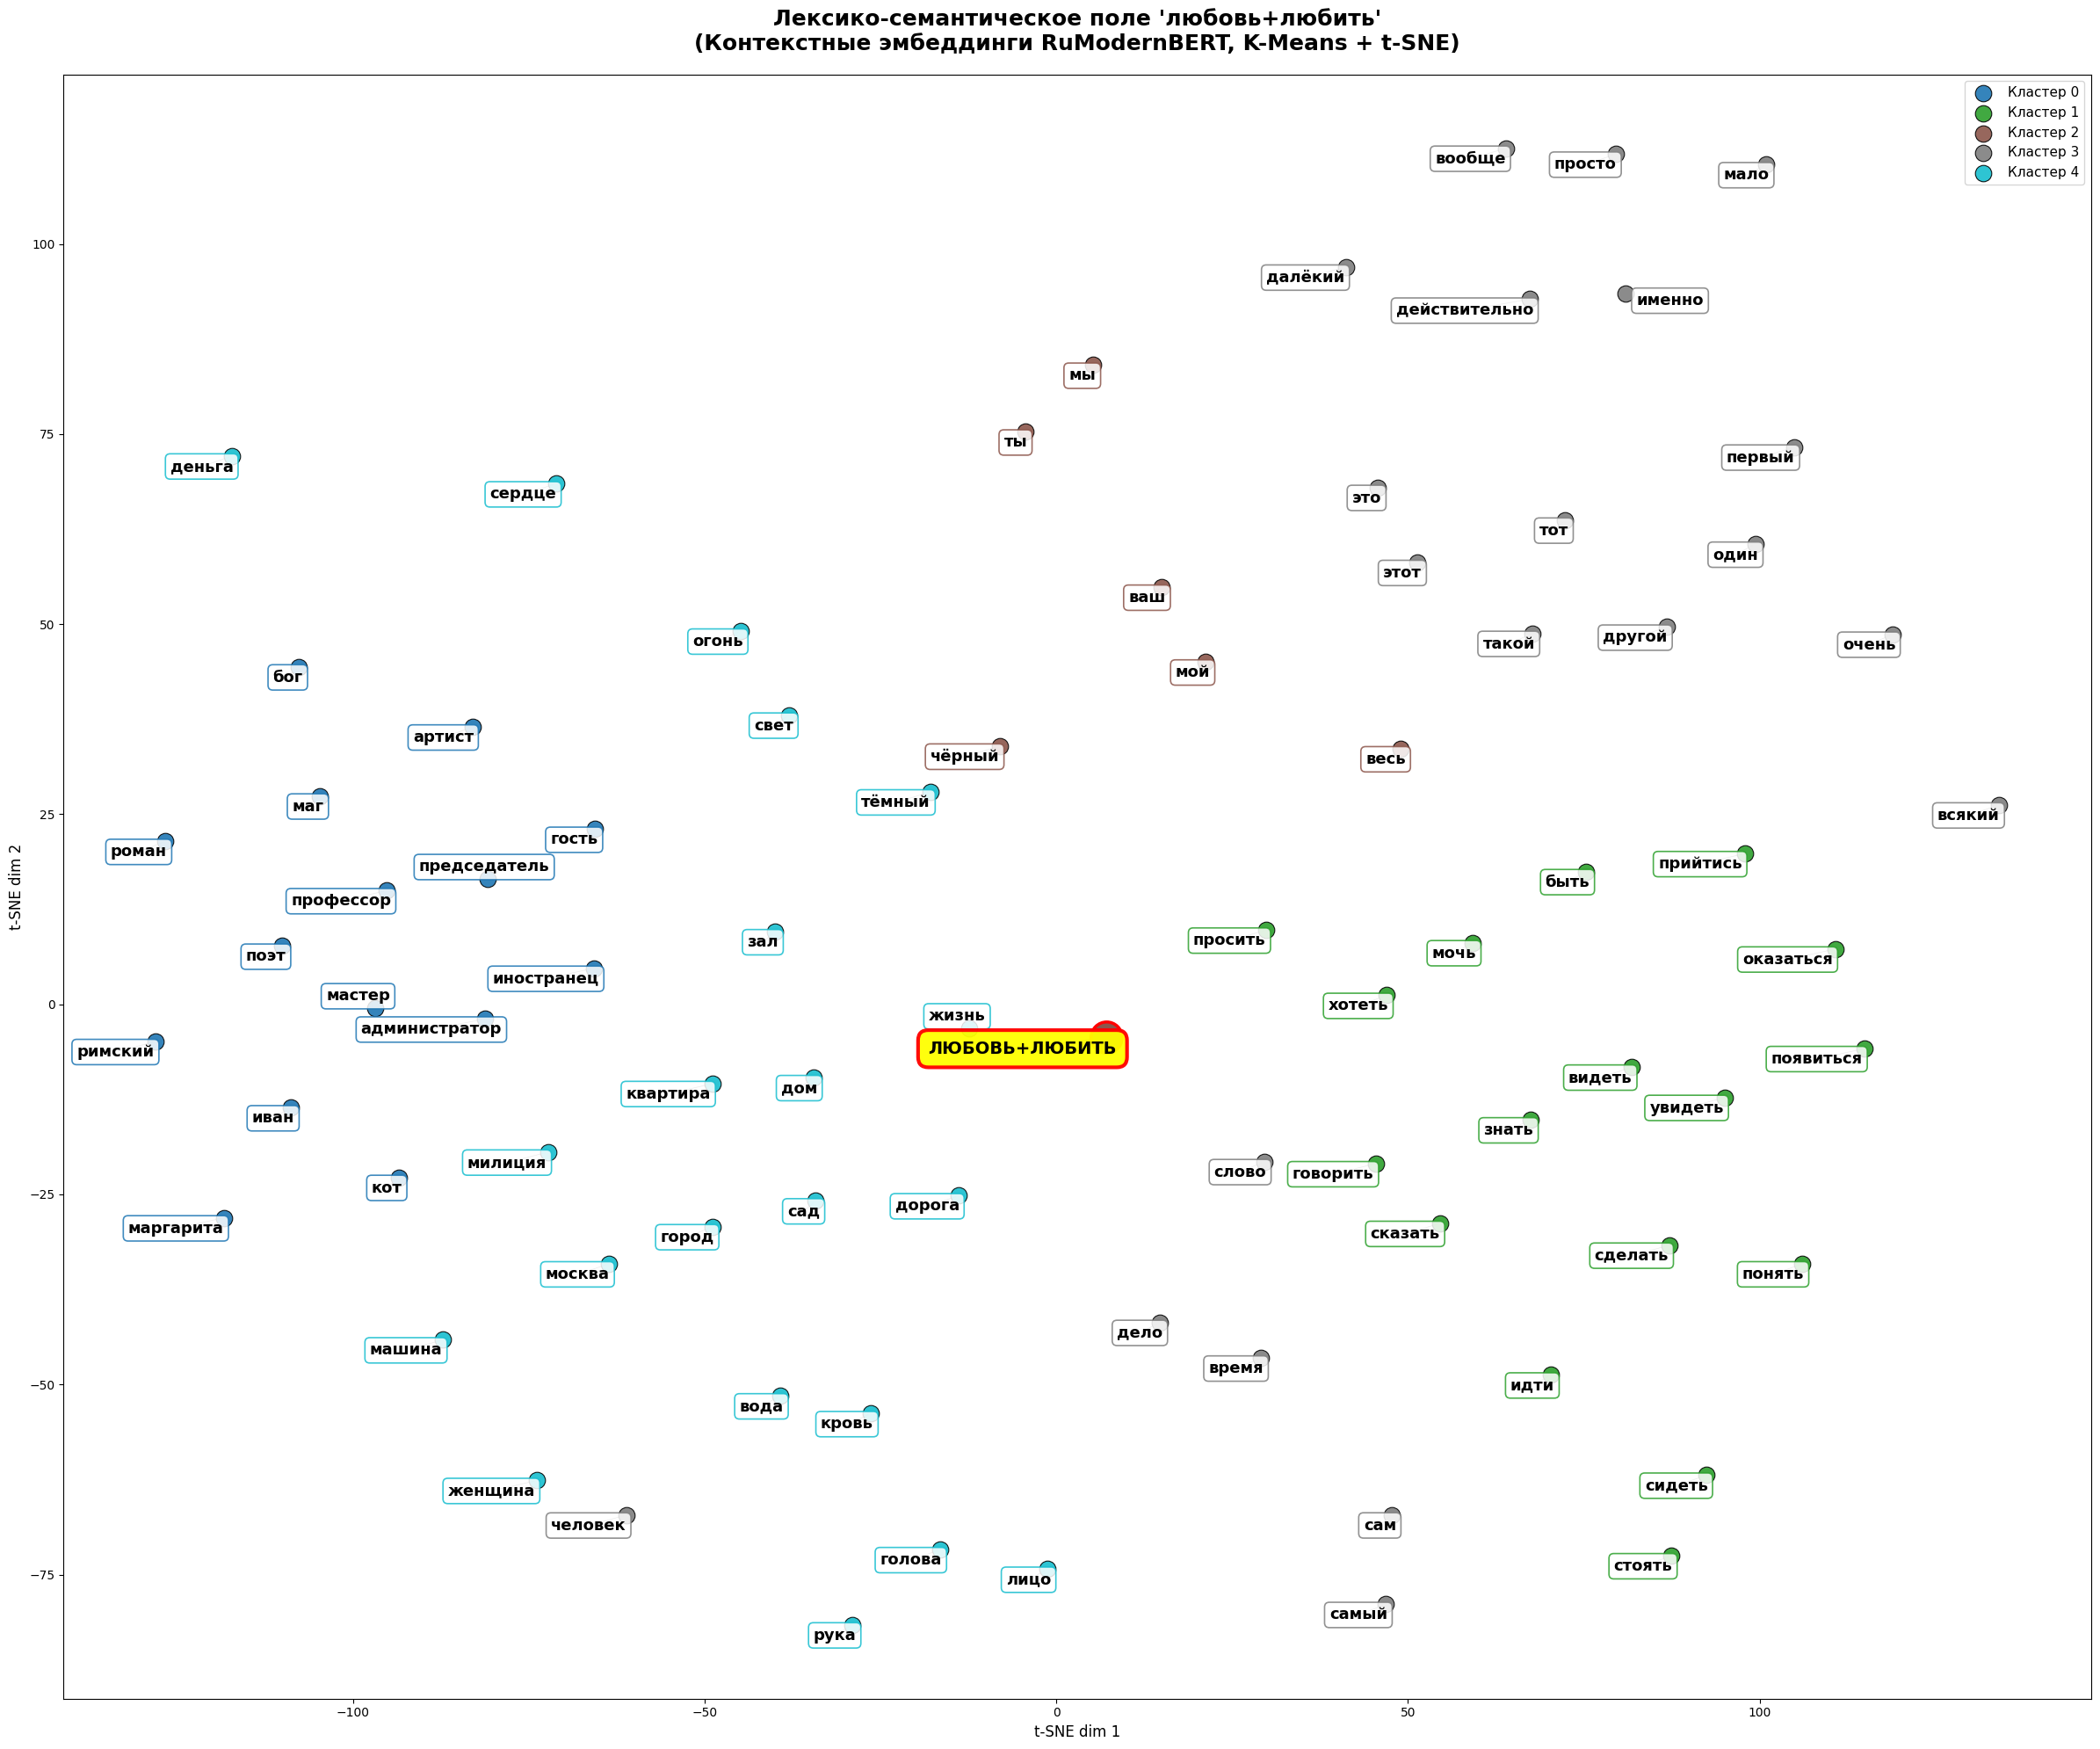


📈 Top-20 ассоциатов к 'любовь+любить' (в контексте романа):

 1. видеть               similarity=0.8794  кластер=1 (зелёный)
 2. говорить             similarity=0.8792  кластер=1 (зелёный)
 3. жизнь                similarity=0.8769  кластер=4 (голубой)
 4. человек              similarity=0.8766  кластер=3 (серый)
 5. дорога               similarity=0.8761  кластер=4 (голубой)
 6. женщина              similarity=0.8752  кластер=4 (голубой)
 7. гость                similarity=0.8751  кластер=0 (синий)
 8. хотеть               similarity=0.8745  кластер=1 (зелёный)
 9. весь                 similarity=0.8728  кластер=2 (коричневый)
10. кровь                similarity=0.8725  кластер=4 (голубой)
11. дом                  similarity=0.8721  кластер=4 (голубой)
12. поэт                 similarity=0.8718  кластер=0 (синий)
13. город                similarity=0.8698  кластер=4 (голубой)
14. вода                 similarity=0.8693  кластер=4 (голубой)
15. мой                  similarity=0.8689  к

In [ ]:
all_words, vectors_2d, labels, cluster_to_color, cluster_to_color_name = \
    visualize_contextual_semantic_field(
        concept_word="любовь+любить",
        concept_vector=vector_love_avg,
        word2vec_contextual=word2vec_contextual,
        valid_contexts=valid_contexts_combined,
        topn=80,
    )